In [169]:
import numpy as np
import random

In [170]:
# Data preparation
# XOR data
x_seeds = np.array([(0,0), (1,0), (0,1), (1,1)], dtype = np.float64)
y_seeds = np.array([0,1,1,0])

In [171]:
N = 1000
idxs = np.random.randint(0, 4, N)

In [172]:
X = x_seeds[idxs]
Y = y_seeds[idxs]

In [173]:
X += np.random.normal(scale = 0.25, size = X.shape)

In [174]:
# Model
class shallow_neural_network():
    def __init__(self, num_input_features, num_hiddens):
        self.num_input_features = num_input_features
        self.num_hiddens = num_hiddens
        
        self.W1 = np.random.normal(size = (num_hiddens, num_input_features))
        self.b1 = np.random.normal(size = num_hiddens)
        self.W2 = np.random.normal(size = num_hiddens)
        self.b2 = np.random.normal(size = 1)
        
    def sigmoid(self, z):
        return 1/(1 + np.exp(-z))
    
    def predict(self, x):
        z1 = np.matmul(self.W1, x) + self.b1
        a1 = np.tanh(z1)
        z2 = np.matmul(self.W2, a1) + self.b2
        a2 = self.sigmoid(z2)
        return a2, (z1, a1, z2, a2)

In [175]:
model = shallow_neural_network(2,3)

In [176]:
# Train (with vector operations)
def train(X, Y, model, lr = 0.1):
    dW1 = np.zeros_like(model.W1)
    db1 = np.zeros_like(model.b1)
    dW2 = np.zeros_like(model.W2)
    db2 = np.zeros_like(model.b2)
    m = len(X)
    cost = 0.0
    for x, y in zip(X, Y):
        a2, (z1, a1, z2, _) = model.predict(x)
        if y == 1:
            cost -= np.log(a2)
        else:
            cost -= np.log(1 - a2)
        
        diff = a2 - y
        # layer2
        db2 += diff
        dW2 += diff * a1.T
        # layer 1
        db1_tmp = diff * model.W2 * (1 - a1**2)
        db1 += db1_tmp
        dW1 += np.outer(db1_tmp,x)
        
    cost /= m
    model.W1 -= lr * dW1 / m
    model.b1 -= lr * db1 / m
    model.W2 -= lr * dW2 / m
    model.b2 -= lr * db2 / m
    
    return cost

In [177]:
for epoch in range(100):
    cost = train (X, Y, model, 1.0)
    if epoch % 10 == 0:
        print(epoch, cost)

0 [0.97322983]
10 [0.65256411]
20 [0.61610848]
30 [0.57454748]
40 [0.51672578]
50 [0.44238337]
60 [0.37818593]
70 [0.32858378]
80 [0.29095021]
90 [0.26263393]


In [178]:
# Test
model.predict((1,1))[0].item()

0.13973802577531402

In [179]:
model.predict((1,0))[0].item()

0.9633012965180242

In [180]:
model.predict((0,1))[0].item()

0.8960566812199736

In [181]:
model.predict((0,0))[0].item()

0.07159023490506537

In [182]:
# Data plotting
import matplotlib.pyplot as plt

idxs_1 = np.where(Y==1)
idxs_0 = np.where(Y==0)

In [183]:
X_0 = X[idxs_0]
Y_0 = Y[idxs_0]

In [184]:
X_1 = X[idxs_1]
Y_1 = Y[idxs_1]

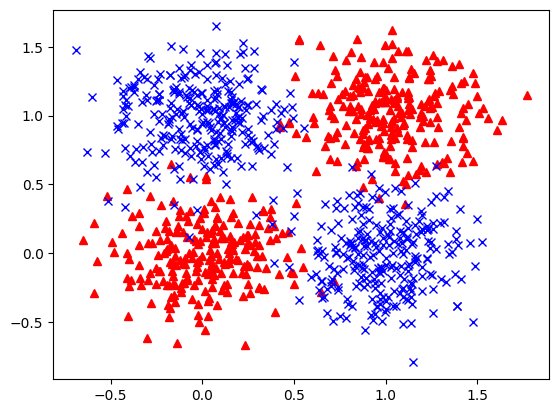

In [185]:
# plt.plot()
plt.plot(X_0[:,0], X_0[:,1], "r^")
plt.plot(X_1[:,0], X_1[:,1], "bx")